

# <u> EXPERIMENT 9 </p>
</u>
Name: Vrishali Sahay </br>
SAP ID: 590011701 </br>
Batch: 19 (AI/ML)




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip install xgboost

In [33]:
import pandas as pd
import numpy as np
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
file_path = '/content/drive/MyDrive/mitbih_test.csv'
df = pd.read_csv(file_path)

df.head()

In [ ]:


X = df.iloc[:, :-1]
y = df.iloc[:, -1]
y = (y != 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    try:
        roc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    except:
        roc = "N/A"
    results.append([name, acc, prec, rec, f1, roc])

results_df = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1 Score","ROC-AUC"])
results_df.sort_values(by="Accuracy", ascending=False)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:58:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,XGBoost,0.971911,0.971741,0.971911,0.971337,0.987598
1,Random Forest,0.967801,0.968274,0.967801,0.966682,0.985916
3,KNN,0.962549,0.961998,0.962549,0.961726,0.959676
0,Decision Tree,0.947477,0.947025,0.947477,0.947224,0.903151
2,Logistic Regression,0.900434,0.894777,0.900434,0.892606,0.881980


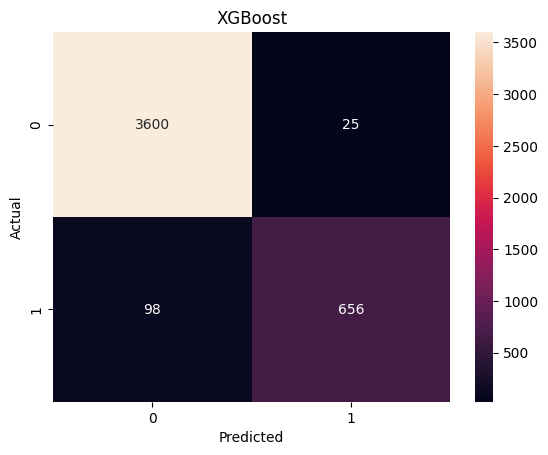

In [34]:
results_df = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1 Score","ROC-AUC"])
results_df.sort_values(by="Accuracy", ascending=False)

best_model_name = results_df.sort_values(by="Accuracy", ascending=False).iloc[0]["Model"]
best_model = trained_models[best_model_name]

y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(best_model_name)
plt.show()
